In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import geopandas as gpd
from ipywidgets import interact, fixed
from IPython.display import clear_output
from sktime.performance_metrics.forecasting import MeanSquaredError as MSEsktime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from matplotlib.colors import ListedColormap, Normalize
from sklearn.metrics import mean_squared_error as mse
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

import os

Below we can specify which `state` were going to analize. If we can to used the saved models, set `load` to `True`.

In [4]:
state = 'OR'
load = True
target = 'customers_out_max' #could also be customers_out

features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
            'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
            't2m', 'sf', 'tp', 't2m_mean', 't2m_max', 'sf_mean', 'sf_max', 'tp_mean',
            'tp_max', 'wind_speed', 'neighbor_max_wind_speed','customers_out_state', 'customers_out','customers_out_max']

# Features for non-engineered merged data:

# features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
#            'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
#            't2m', 'u10', 'v10', 'sf', 'tp', 'customers_out_state', 'customers_out'] 

In [5]:
file_path = os.path.join('..', 'data', 'Merged_data', 'eaglei_noaa_era5_engineered.parquet')
df_state = pd.read_parquet(file_path, filters = [('STUSPS','=',state),('datetime','<',datetime.datetime(2022,1,1))])

In [6]:
df_state

,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,sf_max,tp_mean,tp_max,wind_speed,neighbor_mean_wind_speed,neighbor_max_wind_speed,sf_12h,sf_24h,tp_12h,tp_24h
0,41001,0.000000,2014-01-01 00:00:00,2014,Baker,OR,0.182967,"[41045, 41061, 16087, 41023, 16003, 41063]",NWPP,-117.7,...,0.003034,0.002106,0.004731,0.904166,1.166338,3.676871,NaN,NaN,NaN,NaN
1,41001,0.000000,2014-01-01 06:00:00,2014,Baker,OR,0.182967,"[41045, 41061, 16087, 41023, 16003, 41063]",NWPP,-117.7,...,0.000382,0.000144,0.000384,0.436157,0.258673,1.793668,0.000827,NaN,0.000859,NaN
2,41001,0.000000,2014-01-01 12:00:00,2014,Baker,OR,0.182967,"[41045, 41061, 16087, 41023, 16003, 41063]",NWPP,-117.7,...,0.000408,0.000151,0.000411,0.526522,0.661027,1.668123,0.000118,NaN,0.000167,NaN
3,41001,0.000000,2014-01-01 18:00:00,2014,Baker,OR,0.182967,"[41045, 41061, 16087, 41023, 16003, 41063]",NWPP,-117.7,...,0.000412,0.000153,0.000418,0.453303,0.920155,1.213703,0.000118,0.000945,0.000169,0.001028
4,41001,0.000000,2014-01-02 00:00:00,2014,Baker,OR,0.182967,"[41045, 41061, 16087, 41023, 16003, 41063]",NWPP,-117.7,...,0.000412,0.000153,0.000419,1.381258,0.634969,1.228294,0.000121,0.000239,0.000173,0.000340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409075,41071,26.833333,2021-12-30 18:00:00,2021,Yamhill,OR,0.443075,"[41047, 41005, 41053, 41057, 41067]",NWPP,-123.3,...,0.006907,0.005868,0.006914,2.034583,2.194692,4.526856,0.002305,0.003094,0.005534,0.006487
409076,41071,0.000000,2021-12-31 00:00:00,2021,Yamhill,OR,0.443075,"[41047, 41005, 41053, 41057, 41067]",NWPP,-123.3,...,0.013002,0.009704,0.013705,3.084682,2.845811,4.385785,0.003771,0.004214,0.012451,0.012907
409077,41071,0.000000,2021-12-31 06:00:00,2021,Yamhill,OR,0.443075,"[41047, 41005, 41053, 41057, 41067]",NWPP,-123.3,...,0.006463,0.002278,0.006677,2.028844,1.903559,2.726757,0.001917,0.004222,0.007612,0.013147
409078,41071,0.000000,2021-12-31 12:00:00,2021,Yamhill,OR,0.443075,"[41047, 41005, 41053, 41057, 41067]",NWPP,-123.3,...,0.009458,0.003439,0.009679,1.621076,1.331250,2.116138,0.000090,0.003861,0.000716,0.013167


Below we create a new column with the maximum number of customers over the last 24hrs.

In [583]:
df_state_agg = df_state.groupby('datetime', as_index=True)['customers_out'].sum()

df_state.sort_values(by='datetime',inplace=True)

df_state['customers_out_max'] = df_state.groupby('fips_code')['customers_out'].rolling(4, min_periods=1).max().reset_index(level=0, drop=True)

df_state['customers_out_state'] = df_state['datetime'].map(df_state_agg)

In [584]:
df_state.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
fips_code,409080.0,41035.057143,41001.0,41017.0,41035.0,41053.0,41071.0,20.297728
customers_out,409080.0,35.861267,0.0,0.0,0.0,0.083333,115641.083333,990.367754
datetime,409080,2017-12-31 21:00:00.000000256,2014-01-01 00:00:00,2016-01-01 10:30:00,2017-12-31 21:00:00,2020-01-01 07:30:00,2021-12-31 18:00:00,NaN
YEAR,409080.0,2017.500342,2014.0,2016.0,2017.5,2020.0,2021.0,2.291141
Pct_Buried_Lines,409080.0,0.256654,0.104715,0.162956,0.232807,0.292902,0.605089,0.120971
centroid_longitude,409080.0,-121.525714,-124.2,-123.3,-122.2,-120.2,-117.2,2.059315
centroid_latitude,409080.0,44.485714,42.4,43.3,44.7,45.4,46.0,1.100168
POPULATION,409080.0,109418.085714,1765.0,20978.0,46034.0,107667.0,735334.0,161542.973969
BUILDVALUE,409080.0,11698596000.0,170567000.0,1864522000.0,4907680000.0,10014369000.0,86281316000.0,18253504293.844761
AGRIVALUE,409080.0,141484485.714286,0.0,33797000.0,76543000.0,192598000.0,701580000.0,163385198.830207


We gather all the counties, identified with their FIPS in `fips_list`.

In [585]:
fips_list = df_state.fips_code.unique()
len(fips_list)

35

Since some counties are missing data for some timeframes, we save the min and max date for each fips in `fips_time_ranges`

In [586]:
fips_time_ranges = df_state.groupby('fips_code', as_index=True)['datetime'].agg(['min','max','count'])

## Training using LSTM

Suppose our time series has inputs $x_t$ and outputs $y_t$. With `WINDOW_SIZE=n` and `FORECAST_SIZE=m`, the function `data_to_input_and_output` will transform this into a new timeseries of the following form:

- Input: $z_t = (x_{t-n},x_{t-n+1},\dots,x_{t})$
- Output: $w_t = (y_t,y_{t+1},\dots,y_{t+m-1})$


In [587]:
WINDOW_SIZE = 20

FORECAST_SIZE = 4

def data_to_input_and_output(data,target,features):
    """
    Inputs:
    data - a timeseries in dataframe format, should be longer than WINDOW_SIZE
    target - a string with the name of the target feature
    features - a list with the names of all features used for training, should contain 'target'

    Returns:
    input_data - whose entries will be WINDOW_SIZE consecutive entries of data
    output_data - whose entries will be the element that follows after the WINDOW_SIZE consecutive elements

    For example if data = [0,1,2,3,4,5] and WINDOW_SIZE = 2 then
    input_data      output_data
    [[0,1],         [2,
    [1,2],           3,
    [2,3],           4,
    [3,4]]           5]
    """

    input_data = []
    output_data = []

    for index in range(WINDOW_SIZE,len(data)-FORECAST_SIZE):
        input_sample = data[features].iloc[index-WINDOW_SIZE:index]
        output_sample = data[target].iloc[index:index+FORECAST_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)
    
    return np.array(input_data), np.array(output_data)

The function `lstm_model` takes the input `X`, output `y` and returns an Long Short Term Memory neural network trained on `X` and `y`. This will use the data from $n$ to inputs to predict the following $m$ outputs, where $n$ is the `WINDOW_SIZE` and $m$ is the `FORECAST_SIZE`. You can modify the epochs, learning rate, units and dropout for this model as extra parameters.

In [ ]:
def lstm_model(X, y, epochs = 10, learning_rate=0.005,units = 28,dropout= 0.2 ,validation_data = None):
    """
    Inputs:
    X - the input_data obtained from data_to_input_and_output
    y - the output_data obtained from data_to_input_and_output

    Returns:
    model - a LTSM neural network trained on X and y
    """
    feat_len = X.shape[2]

    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE,feat_len)))
    model.add(LSTM(units,dropout=dropout))
    model.add(Dense(8,'relu'))
    model.add(Dense(FORECAST_SIZE,'linear'))

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    model.fit(X, y, epochs= epochs, verbose=1, validation_data=validation_data)

    return model

Since our data for customers out has mostly zero entries with some sporadic spikes, we will use a `MinMax` and a root to exacerbate these spikes. 

In [589]:
class RMMScaler:
    def __init__(self, feature_range=(0, 1),pwr = 2, copy=True, clip=False):
        self.feature_range = feature_range
        self.copy = copy
        self.clip = clip
        self.pwr = pwr
        self.scaler = MinMaxScaler(feature_range=self.feature_range, copy=self.copy, clip=self.clip)
    
    def fit(self,X,y=None):
        return self.scaler.fit(X)
    
    def transform(self,X):
        return np.power(self.scaler.transform(X),1/(self.pwr))
    def inverse_transform(self,X):
        return self.scaler.inverse_transform(np.power(X,self.pwr))

We will only scale the inputs, train the model over each county individually and save each model.

In [ ]:
if load:
    n_splits = 2
else:
    n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

metrics = {fips: [] for fips in fips_list} # contains the metrics for the model on each split
time_indices = {fips: [] for fips in fips_list} # contains a tuple with the indices for each train and test split
train_results = {fips: [] for fips in fips_list}
test_results = {fips: [] for fips in fips_list}

for fips in fips_list:
    
    df_county = df_state[df_state['fips_code']==fips]
    start_t = fips_time_ranges.loc[fips]['min']
    end_t = fips_time_ranges.loc[fips]['max']
    
    for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
        
        clear_output(wait=False)
        print(f'Split #{i+1} for fips: {int(fips)}')

        df_train = df_county.iloc[train_index]
        df_test = df_county.iloc[test_index]
        time_indices[fips].append([train_index,test_index])
        
        mm = RMMScaler(feature_range=(0,1), clip=True, pwr = 4)
        mm.fit(df_train[features])
        df_train_scaled = pd.DataFrame(mm.transform(df_train[features]),columns=features)
        df_test_scaled = pd.DataFrame(mm.transform(df_test[features]),columns=features)

        _ , train_output = data_to_input_and_output(df_train,target,features)
        _ , test_output = data_to_input_and_output(df_test,target,features)

        train_input_scaled , _ = data_to_input_and_output(df_train_scaled,target,features)
        test_input_scaled , _ = data_to_input_and_output(df_test_scaled,target,features)

        if load:
            K.clear_session()
            model = load_model(f'../Results/LSTM/model/LSTM_{state}_{fips}.keras', compile=False)
        else:
            model = lstm_model(train_input_scaled, train_output,dropout=0.2,validation_data=(test_input_scaled,test_output))
            metrics[fips].append(model.get_metrics_result())

        train_pred = model.predict(train_input_scaled)
        test_pred = model.predict(test_input_scaled)

        train_actual_result = pd.DataFrame({'Actual':df_train[target].values}, index = df_train['datetime'])
        train_pred_result = pd.DataFrame({'Predicted':train_pred[:,0]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE:-FORECAST_SIZE]])
        train_forecast_result = pd.DataFrame({'Forecast':train_pred[:,-1]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE+FORECAST_SIZE:]])
        train_results[fips].append(pd.concat([train_actual_result,train_pred_result,train_forecast_result], axis=1))

        test_actual_result = pd.DataFrame({'Actual':df_test[target].values}, index = df_test['datetime'])
        test_pred_result = pd.DataFrame({'Predicted':test_pred[:,0]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE:-FORECAST_SIZE]])
        test_forecast_result = pd.DataFrame({'Forecast':test_pred[:,-1]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE+FORECAST_SIZE:]])
        test_results[fips].append(pd.concat([test_actual_result,test_pred_result,test_forecast_result], axis=1))
    
    if not load:
        saved_path = f'../Results/LSTM/model/LSTM_{state}_{fips}.keras'
        model.save(saved_path)

#Took 2 hours to train on 90 counties
#Took 1 hour to predict on already trained models for South Carolina :(

Split #2 for fips: 41035
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [591]:
model.summary()

Model: "sequential_174"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_174 (LSTM)                 │ (None, 28)             │         5,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_348 (Dense)               │ (None, 8)              │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_349 (Dense)               │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,980 (23.36 KB)

 Trainable params: 5,980 (23.36 KB)

 Non-trainable params: 0 (0.00 B)

## RMSEs for all counties

Below we have the RMSE for each county in the state.

In [599]:
rmses_state = {}

for fips in fips_list:
    x = test_results[fips][-1]
    x1 = train_results[fips][-1]
    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    common_indicesf = x['Actual'].dropna().index.intersection(x['Forecast'].dropna().index)
    common_indices1 = x1['Actual'].dropna().index.intersection(x1['Predicted'].dropna().index)
    common_indices1f = x1['Actual'].dropna().index.intersection(x1['Forecast'].dropna().index)
    rmse = MSEsktime(square_root=True)
    
    rmses_state[('train','Predicted',str(fips))] = round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)
    rmses_state[('train','Forecast',str(fips))] = round(rmse(x['Actual'].loc[common_indices],x['Forecast'].loc[common_indices]),3)
    rmses_state[('test','Predicted',str(fips))] = round(rmse(x1['Actual'].loc[common_indices1],x1['Predicted'].loc[common_indices1]),3)
    rmses_state[('test','Forecast',str(fips))] = round(rmse(x1['Actual'].loc[common_indices1],x1['Forecast'].loc[common_indices1]),3)

df_rmses = pd.DataFrame.from_dict(rmses_state,orient='index',columns=['RMSE'])

population_by_fips = df_state.groupby('fips_code')['POPULATION'].mean().reset_index()
population_by_fips.set_index('fips_code',inplace=True)
population_by_fips.index = population_by_fips.index.astype(str)

df_rmses['FIPS'] = df_rmses.index.map(lambda x: x[-1])
df_rmses['Population'] =  df_rmses['FIPS'].map(population_by_fips['POPULATION'])
df_rmses['Relative RMSE'] = df_rmses['RMSE']/df_rmses['Population']

pd.MultiIndex.from_tuples(df_rmses.index, names=['data','type','fips'])
df_rmses = df_rmses.set_index(pd.MultiIndex.from_tuples(df_rmses.index, names=['data','type','fips']))

df_rmses


c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


RMSE   FIPS  Population  Relative RMSE
data  type      fips                                            
train Predicted 41001  106.624  41001     16134.0       0.006609
      Forecast  41001  118.506  41001     16134.0       0.007345
test  Predicted 41001   17.219  41001     16134.0       0.001067
      Forecast  41001   23.717  41001     16134.0       0.001470
train Predicted 41021    6.575  41021      1871.0       0.003514
...                        ...    ...         ...            ...
test  Forecast  41049   26.516  41049     11173.0       0.002373
train Predicted 41035  121.052  41035     66380.0       0.001824
      Forecast  41035  155.649  41035     66380.0       0.002345
test  Predicted 41035   56.026  41035     66380.0       0.000844
      Forecast  41035   77.493  41035     66380.0       0.001167

[140 rows x 4 columns]

We can get statistical summaries for the RMSE's for predicted or forecast results using train or test data:

In [600]:
df_rmses['Relative RMSE'].loc['test','Forecast',:].describe()

count    35.000000
mean      0.002244
std       0.002250
min       0.000036
25%       0.000847
50%       0.001710
75%       0.002598
max       0.010209
Name: Relative RMSE, dtype: float64

In [ ]:
def plot_rmse_on_map_state(df,feature,state=state,data='train',comp='Predicted'):
    
    loc = '../data/NWS_US_Counties_Shapefiles/c_05mr24.shp'
    counties = gpd.read_file(loc)

    counties = counties[counties['STATE'] == state]
    counties.set_index('FIPS', inplace=True)
    
    df.index = df.index.set_levels(df.index.levels[2].str.zfill(5), level=2)

    df_filtered = df.loc[data,comp,:]

    counties = counties.join(df_filtered,how='left')

    # Create a custom colormap
    viridis_cmap = plt.cm.viridis  # Base colormap
    colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
    colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
    custom_cmap = ListedColormap(colors)
    
    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    county_plot = counties.plot(column=feature,  # Data to visualize
                                cmap=custom_cmap,  # Colormap
                                linewidth=0.8,
                                ax=ax,
                                edgecolor='black',
                                legend=False,  # Disable automatic colorbar
                                norm=Normalize(vmin=0, vmax=counties[feature].max())  # Normalize scale
                               )
    
    # Add colorbar and set its title
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties[feature].max()))
    sm._A = []  # Dummy array for the ScalarMappable
    cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.set_xlabel('RMSE', fontsize=14)
    
    # Remove the vertical label
    cbar.ax.set_ylabel('')
    
    # Customize the plot
    title = f"{feature} for \n {comp.lower()} results using {data} data \n in each county in {state}"
    ax.set_title(title, fontsize=14)
    ax.axis('off')  # Turn off the axis
    plt.show()

    return


and here a map to visualize where the RMSE is the highest. This should be compared to the map that shows the outages for the time period.

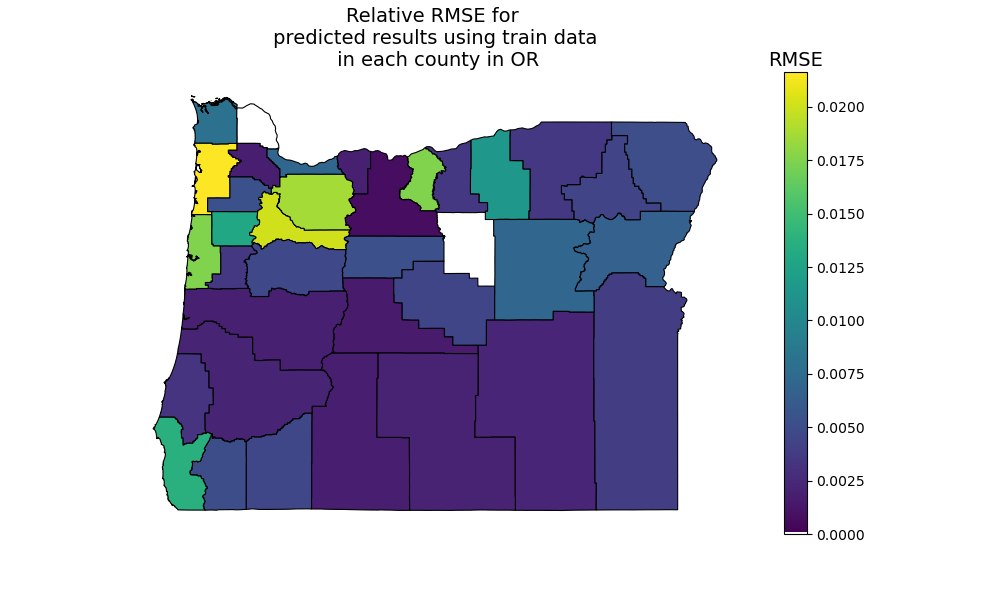

In [595]:
plot_rmse_on_map_state(df_rmses,feature='Relative RMSE',state=state,data='train',comp='Predicted')

Below we save our RMSE's for each county in this state together with their geometry.

In [ ]:
df_rmses.to_csv(f'../Results/LSTM/results/RMSE_LSTM_{state}',index=True)

#Note: to read this use pd.read_csv(f'../Results/LSTM/results/RMSE_LSTM_{state}',index_col = [0,1,2])

## Plots of predictions and forecasts

Below we have an interactive plot to visualize our results for predictions and 24hr forecasts on both the train and test data.

In [597]:
results = {}
results['train'] = train_results
results['test'] = test_results

def plotit(df=results, rmsedf = df_rmses, data = 'test', subtitle = 'Relative RMSE',comp = 'Forecast',fips_choice = fips_list[-1],start_year=2014, end_year=2021):
    
    if start_year > end_year:
        print("You must select a start year that is prior to end year")
    else:
        x = df[data][fips_choice][-1]
        
        x = x.loc[f'{int(start_year)}-01-01':f'{int(end_year)+1}-01-01']

        # Plot it (only if there's data to plot)
        if len(x) > 0:
            fig, ax = plt.subplots()
            l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
            l1 = ax.plot(x[comp],label = comp,alpha = 0.8)
            ax.legend()
            ax.set_xlabel('time')
            ax.set_ylabel(target)

            rmse_val = round(rmsedf.loc[[(data,comp,str(fips_choice))]][subtitle].values[0],5)

            ax.set_title(f'Results on {data} data for FIPS={int(fips_choice)} \n {subtitle} for all entries ={rmse_val}')
            plt.xticks(rotation=90)
            plt.show()
        else:
            print("No data to show for current selection")

In [ ]:
interact(plotit,df=fixed(results), rmsedf = fixed(df_rmses), data = ['test','train'], subtitle=fixed('Relative RMSE'),comp=['Forecast','Predicted'],fips_choice= fips_list, start_year = (2014,2021,1), end_year = (2014,2021,1));

interactive(children=(Dropdown(description='data', options=('test', 'train'), value='test'), Dropdown(descript…